# RQ1 — Pre-training Quality Analysis

This notebook inspects one run produced by `run_pretraining_quality.py`.

The main quantities are $\epsilon_S(t) = \frac{\|S(W_t)-S^\star\|_F^2}{\|S^\star\|_F^2}$ and the held-out pre-training generalization error $\epsilon_{\mathrm{pre}}(t).$

We inspect them against:
- raw SGD update count `step`;
- \(t/d\);
- \(t/d^2\).

The goal is to decide whether the current pre-training trajectory has converged enough and which saved checkpoints represent meaningfully different levels of pre-training quality before moving on to Task 1.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


Loaded runs:
d=100  | step=  400,000 | t/d=4000.000 | t/d²=40.000 | eps_S=2.548949e-02 | eps_pre=7.085402e-03 | q=1.753251e+02 | max|eps_S - eps_S(OP)|=1.048e-15
d=200  | step=1,600,000 | t/d=8000.000 | t/d²=40.000 | eps_S=2.748147e-02 | eps_pre=7.502077e-03 | q=3.592574e+02 | max|eps_S - eps_S(OP)|=1.180e-15
d=500  | step=10,000,000 | t/d=20000.000 | t/d²=40.000 | eps_S=2.640734e-02 | eps_pre=7.141501e-03 | q=9.068323e+02 | max|eps_S - eps_S(OP)|=8.119e-16


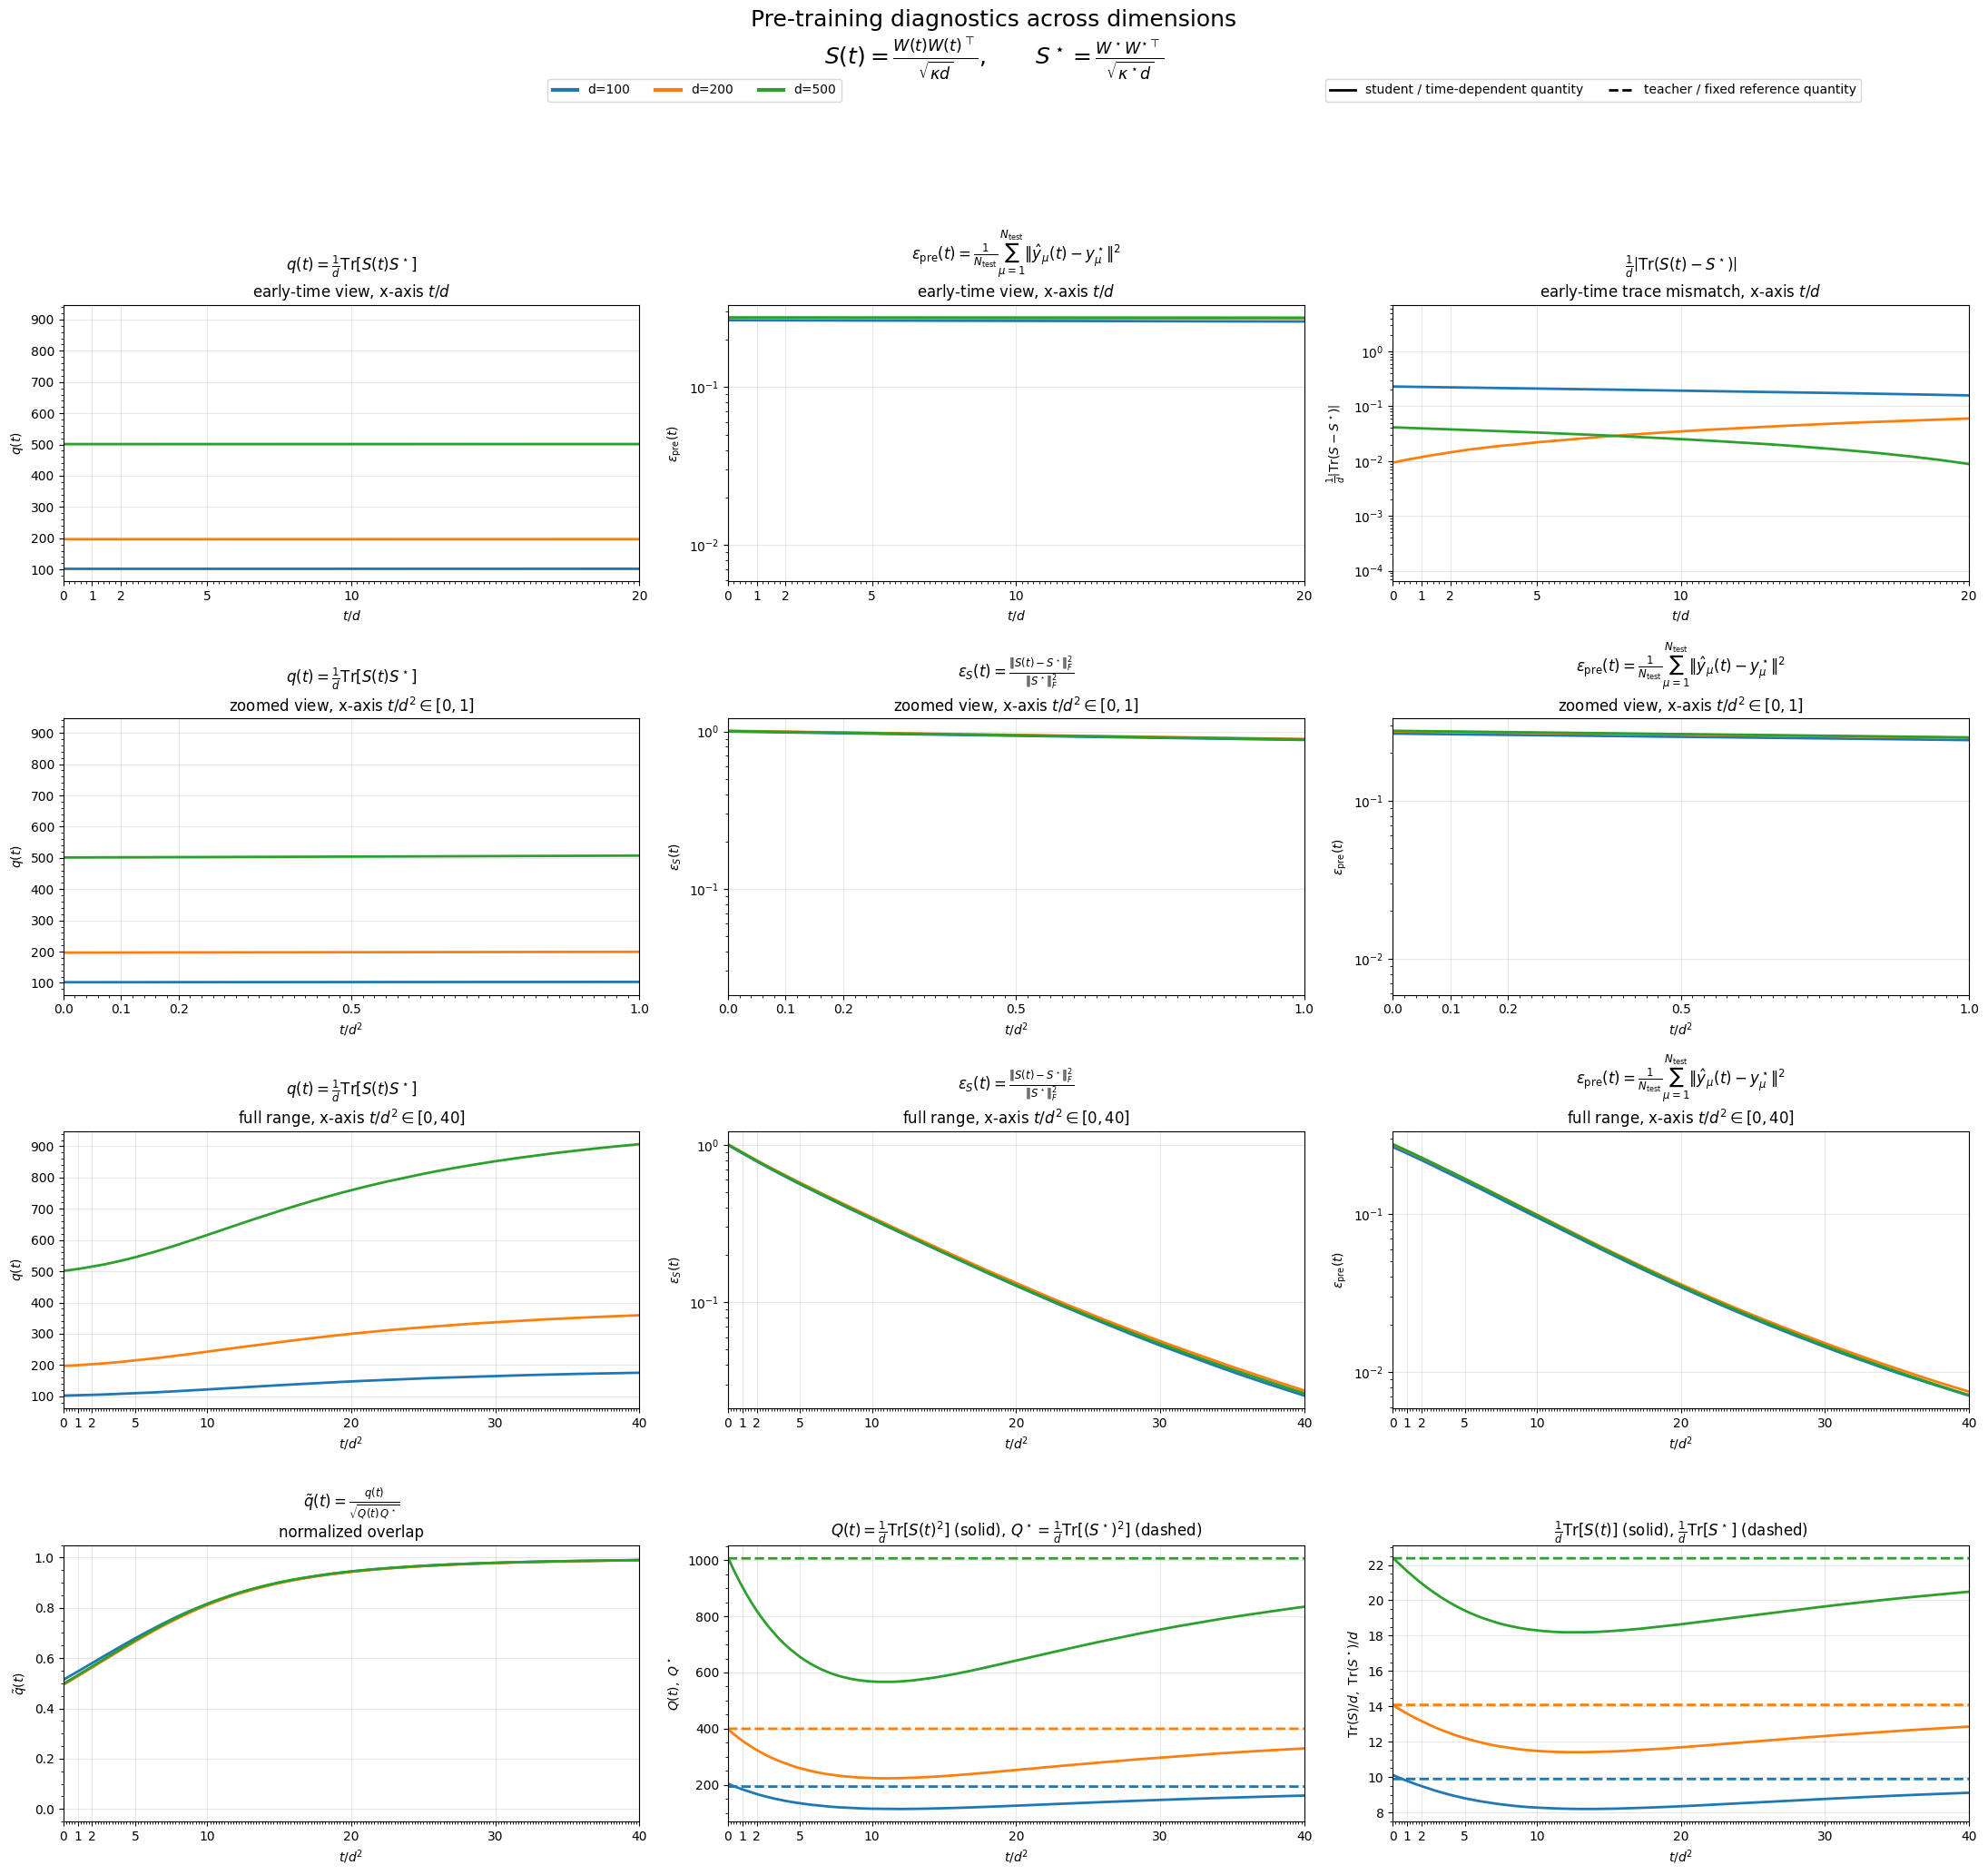

In [2]:
RUNS = {
    "d=100": {"name": "scaling_d100_T5", "d": 100},
    "d=200": {"name": "scaling_d200_T5", "d": 200},
    "d=500": {"name": "scaling_d500_T5", "d": 500},
}

MAX_ALPHA = 40.0   # full x-range in t / d^2
EARLY_T_OVER_D_MAX = 20.0
ZOOM_ALPHA_MAX = 1.0

REQUIRED_COLUMNS = [
    "step",
    "representation_error",
    "generalization_error",
    "q",
    "Q",
    "Q_star",
    "normalized_overlap",
    "trace_S",
    "trace_S_star",
    "trace_mismatch",
]


# ------------------------------------------------------------
# Locate results root
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "results").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "results").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RESULTS_ROOT = REPO_ROOT / "results" / "quality_pretraining"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def positive_only(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    y[y <= 0] = np.nan
    return y


def configure_axis(ax, xlabel, ylabel, xlim=None, xticks=None, yscale=None):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yscale is not None:
        ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()


# ------------------------------------------------------------
# Load runs
# ------------------------------------------------------------

runs = {}
missing_runs = []

for label, info in RUNS.items():
    run_dir = RESULTS_ROOT / info["name"]
    metrics_path = run_dir / "metrics.csv"

    if not metrics_path.exists():
        missing_runs.append(f"{label}: missing {metrics_path}")
        continue

    df = pd.read_csv(metrics_path)
    df = (
        df.sort_values("step")
          .drop_duplicates(subset="step", keep="last")
          .reset_index(drop=True)
    )

    # Recompute time axes explicitly
    d = info["d"]
    df["step_over_d"] = df["step"] / d
    df["step_over_d2"] = df["step"] / (d ** 2)

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        missing_runs.append(
            f"{label}: missing columns {missing_cols} in {metrics_path}"
        )
        continue

    # Sanity check: reconstruct eps_S from q,Q,Q*
    # eps_S = (Q + Q* - 2 q) / Q*
    df["representation_error_from_OP"] = (
        (df["Q"] + df["Q_star"] - 2.0 * df["q"]) / df["Q_star"]
    )
    df["representation_error_check_abs"] = np.abs(
        df["representation_error"] - df["representation_error_from_OP"]
    )

    runs[label] = {
        "df": df,
        "d": d,
        "path": metrics_path,
    }

if missing_runs:
    print("Warnings:")
    for msg in missing_runs:
        print(" -", msg)
    print()

if not runs:
    raise RuntimeError(
        "No valid runs could be loaded. "
        "Check that the rerun metrics.csv files exist and include the new columns."
    )


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

print("Loaded runs:")
for label, payload in runs.items():
    df = payload["df"]
    d = payload["d"]
    last = df.iloc[-1]
    print(
        f"{label:6s} | "
        f"step={int(last['step']):>9,d} | "
        f"t/d={last['step_over_d']:.3f} | "
        f"t/d²={last['step_over_d2']:.3f} | "
        f"eps_S={last['representation_error']:.6e} | "
        f"eps_pre={last['generalization_error']:.6e} | "
        f"q={last['q']:.6e} | "
        f"max|eps_S - eps_S(OP)|="
        f"{df['representation_error_check_abs'].max():.3e}"
    )


# ------------------------------------------------------------
# Color map shared across all subplots
# ------------------------------------------------------------

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {}
for i, label in enumerate(runs.keys()):
    color_map[label] = default_colors[i % len(default_colors)]


# ------------------------------------------------------------
# Figure layout
# 4 rows x 3 columns = 12 panels
# ------------------------------------------------------------

fig, axes = plt.subplots(
    4, 3,
    figsize=(22, 20),
)

# Useful tick locations
ticks_td_early = [0, 1, 2, 5, 10, 20]
ticks_alpha_zoom = [0, 0.1, 0.2, 0.5, 1.0]
ticks_alpha_full = [0, 1, 2, 5, 10, 20, 30, 40]


# ------------------------------------------------------------
# Plot all runs
# ------------------------------------------------------------

for label, payload in runs.items():
    df = payload["df"]
    color = color_map[label]

    # ---------- Row 1: early-time O(d) regime (x = t/d)
    axes[0, 0].plot(
        df["step_over_d"], df["q"],
        lw=2, color=color
    )

    axes[0, 1].plot(
        df["step_over_d"], positive_only(df["generalization_error"]),
        lw=2, color=color
    )

    axes[0, 2].plot(
        df["step_over_d"], positive_only(df["trace_mismatch"]),
        lw=2, color=color
    )

    # ---------- Row 2: zoomed O(d^2) regime (x = t/d^2 in [0,1])
    axes[1, 0].plot(
        df["step_over_d2"], df["q"],
        lw=2, color=color
    )

    axes[1, 1].plot(
        df["step_over_d2"], positive_only(df["representation_error"]),
        lw=2, color=color
    )

    axes[1, 2].plot(
        df["step_over_d2"], positive_only(df["generalization_error"]),
        lw=2, color=color
    )

    # ---------- Row 3: full range (x = t/d^2 in [0,40])
    axes[2, 0].plot(
        df["step_over_d2"], df["q"],
        lw=2, color=color
    )

    axes[2, 1].plot(
        df["step_over_d2"], positive_only(df["representation_error"]),
        lw=2, color=color
    )

    axes[2, 2].plot(
        df["step_over_d2"], positive_only(df["generalization_error"]),
        lw=2, color=color
    )

    # ---------- Row 4: additional order parameters / trace diagnostics
    axes[3, 0].plot(
        df["step_over_d2"], df["normalized_overlap"],
        lw=2, color=color
    )

    axes[3, 1].plot(
        df["step_over_d2"], df["Q"],
        lw=2, color=color
    )
    axes[3, 1].plot(
        df["step_over_d2"], df["Q_star"],
        lw=2, ls="--", color=color
    )

    axes[3, 2].plot(
        df["step_over_d2"], df["trace_S"],
        lw=2, color=color
    )
    axes[3, 2].plot(
        df["step_over_d2"], df["trace_S_star"],
        lw=2, ls="--", color=color
    )


# ------------------------------------------------------------
# Titles with explicit LaTeX formulas
# ------------------------------------------------------------

axes[0, 0].set_title(
    r"$q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)S^\star\right]$"
    "\n"
    r"early-time view, x-axis $t/d$"
)

axes[0, 1].set_title(
    r"$\epsilon_{\mathrm{pre}}(t)=\frac{1}{N_{\mathrm{test}}}"
    r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
    r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    "\n"
    r"early-time view, x-axis $t/d$"
)

axes[0, 2].set_title(
    r"$\frac{1}{d}\left|\operatorname{Tr}\!\left(S(t)-S^\star\right)\right|$"
    "\n"
    r"early-time trace mismatch, x-axis $t/d$"
)

axes[1, 0].set_title(
    r"$q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)S^\star\right]$"
    "\n"
    r"zoomed view, x-axis $t/d^2\in[0,1]$"
)

axes[1, 1].set_title(
    r"$\epsilon_S(t)=\frac{\|S(t)-S^\star\|_F^2}{\|S^\star\|_F^2}$"
    "\n"
    r"zoomed view, x-axis $t/d^2\in[0,1]$"
)

axes[1, 2].set_title(
    r"$\epsilon_{\mathrm{pre}}(t)=\frac{1}{N_{\mathrm{test}}}"
    r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
    r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    "\n"
    r"zoomed view, x-axis $t/d^2\in[0,1]$"
)

axes[2, 0].set_title(
    r"$q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)S^\star\right]$"
    "\n"
    r"full range, x-axis $t/d^2\in[0,40]$"
)

axes[2, 1].set_title(
    r"$\epsilon_S(t)=\frac{\|S(t)-S^\star\|_F^2}{\|S^\star\|_F^2}$"
    "\n"
    r"full range, x-axis $t/d^2\in[0,40]$"
)

axes[2, 2].set_title(
    r"$\epsilon_{\mathrm{pre}}(t)=\frac{1}{N_{\mathrm{test}}}"
    r"\sum_{\mu=1}^{N_{\mathrm{test}}}"
    r"\|\hat y_\mu(t)-y_\mu^\star\|^2$"
    "\n"
    r"full range, x-axis $t/d^2\in[0,40]$"
)

axes[3, 0].set_title(
    r"$\tilde q(t)=\frac{q(t)}{\sqrt{Q(t)\,Q^\star}}$"
    "\n"
    r"normalized overlap"
)

axes[3, 1].set_title(
    r"$Q(t)=\frac{1}{d}\operatorname{Tr}\!\left[S(t)^2\right]$"
    r" (solid), "
    r"$Q^\star=\frac{1}{d}\operatorname{Tr}\!\left[(S^\star)^2\right]$"
    r" (dashed)"
)

axes[3, 2].set_title(
    r"$\frac{1}{d}\operatorname{Tr}\!\left[S(t)\right]$"
    r" (solid), "
    r"$\frac{1}{d}\operatorname{Tr}\!\left[S^\star\right]$"
    r" (dashed)"
)


# ------------------------------------------------------------
# Axis labels, scales, and ticks
# ------------------------------------------------------------

# Row 1: early t/d
configure_axis(
    axes[0, 0],
    xlabel=r"$t/d$",
    ylabel=r"$q(t)$",
    xlim=(0, EARLY_T_OVER_D_MAX),
    xticks=ticks_td_early,
)

configure_axis(
    axes[0, 1],
    xlabel=r"$t/d$",
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    xlim=(0, EARLY_T_OVER_D_MAX),
    xticks=ticks_td_early,
    yscale="log",
)

configure_axis(
    axes[0, 2],
    xlabel=r"$t/d$",
    ylabel=r"$\frac{1}{d}\left|\operatorname{Tr}(S-S^\star)\right|$",
    xlim=(0, EARLY_T_OVER_D_MAX),
    xticks=ticks_td_early,
    yscale="log",
)

# Row 2: zoom t/d^2 in [0,1]
configure_axis(
    axes[1, 0],
    xlabel=r"$t/d^2$",
    ylabel=r"$q(t)$",
    xlim=(0, ZOOM_ALPHA_MAX),
    xticks=ticks_alpha_zoom,
)

configure_axis(
    axes[1, 1],
    xlabel=r"$t/d^2$",
    ylabel=r"$\epsilon_S(t)$",
    xlim=(0, ZOOM_ALPHA_MAX),
    xticks=ticks_alpha_zoom,
    yscale="log",
)

configure_axis(
    axes[1, 2],
    xlabel=r"$t/d^2$",
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    xlim=(0, ZOOM_ALPHA_MAX),
    xticks=ticks_alpha_zoom,
    yscale="log",
)

# Row 3: full t/d^2 in [0,40]
configure_axis(
    axes[2, 0],
    xlabel=r"$t/d^2$",
    ylabel=r"$q(t)$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
)

configure_axis(
    axes[2, 1],
    xlabel=r"$t/d^2$",
    ylabel=r"$\epsilon_S(t)$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
    yscale="log",
)

configure_axis(
    axes[2, 2],
    xlabel=r"$t/d^2$",
    ylabel=r"$\epsilon_{\mathrm{pre}}(t)$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
    yscale="log",
)

# Row 4: additional OPs
configure_axis(
    axes[3, 0],
    xlabel=r"$t/d^2$",
    ylabel=r"$\tilde q(t)$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
)

configure_axis(
    axes[3, 1],
    xlabel=r"$t/d^2$",
    ylabel=r"$Q(t),\ Q^\star$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
)

configure_axis(
    axes[3, 2],
    xlabel=r"$t/d^2$",
    ylabel=r"$\operatorname{Tr}(S)/d,\ \operatorname{Tr}(S^\star)/d$",
    xlim=(0, MAX_ALPHA),
    xticks=ticks_alpha_full,
)

# Normalized overlap is bounded
axes[3, 0].set_ylim(-0.05, 1.05)


# ------------------------------------------------------------
# Global legends
# ------------------------------------------------------------

run_handles = [
    Line2D([0], [0], color=color_map[label], lw=3, label=label)
    for label in runs.keys()
]

style_handles = [
    Line2D([0], [0], color="black", lw=2, ls="-", label="student / time-dependent quantity"),
    Line2D([0], [0], color="black", lw=2, ls="--", label="teacher / fixed reference quantity"),
]

fig.legend(
    handles=run_handles,
    loc="upper center",
    bbox_to_anchor=(0.35, 0.995),
    ncol=len(run_handles),
    frameon=True,
)

fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.80, 0.995),
    ncol=2,
    frameon=True,
)


# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.suptitle(
    "Pre-training diagnostics across dimensions\n"
    r"$S(t)=\frac{W(t)W(t)^\top}{\sqrt{\kappa d}}, \qquad "
    r"S^\star=\frac{W^\star W^{\star\top}}{\sqrt{\kappa^\star d}}$",
    fontsize=18,
    y=1.03,
)

plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

## Step 2: finetuning w with task 1

### d = 100

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,0,910,9.1,0.999314,0.265647,0.338116,-0.109687,0.010112
92,0,920,9.2,0.999314,0.265647,0.338116,-0.109832,0.010112
93,0,930,9.3,0.999314,0.265647,0.338116,-0.109930,0.010114
94,0,940,9.4,0.999314,0.265647,0.338116,-0.110253,0.010118
95,0,950,9.5,0.999314,0.265647,0.338116,-0.110877,0.010115
96,0,960,9.6,0.999314,0.265647,0.338116,-0.111194,0.010117
97,0,970,9.7,0.999314,0.265647,0.338116,-0.112200,0.010124
98,0,980,9.8,0.999314,0.265647,0.338116,-0.112403,0.010128
99,0,990,9.9,0.999314,0.265647,0.338116,-0.112450,0.010128
100,0,1000,10.0,0.999314,0.265647,0.338116,-0.112130,0.010129


pretraining checkpoint : 0
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 3.381160e-01
Pretraining error      : 2.656469e-01
Overlap with w1*       : -0.112130
||w||                  : 0.010129


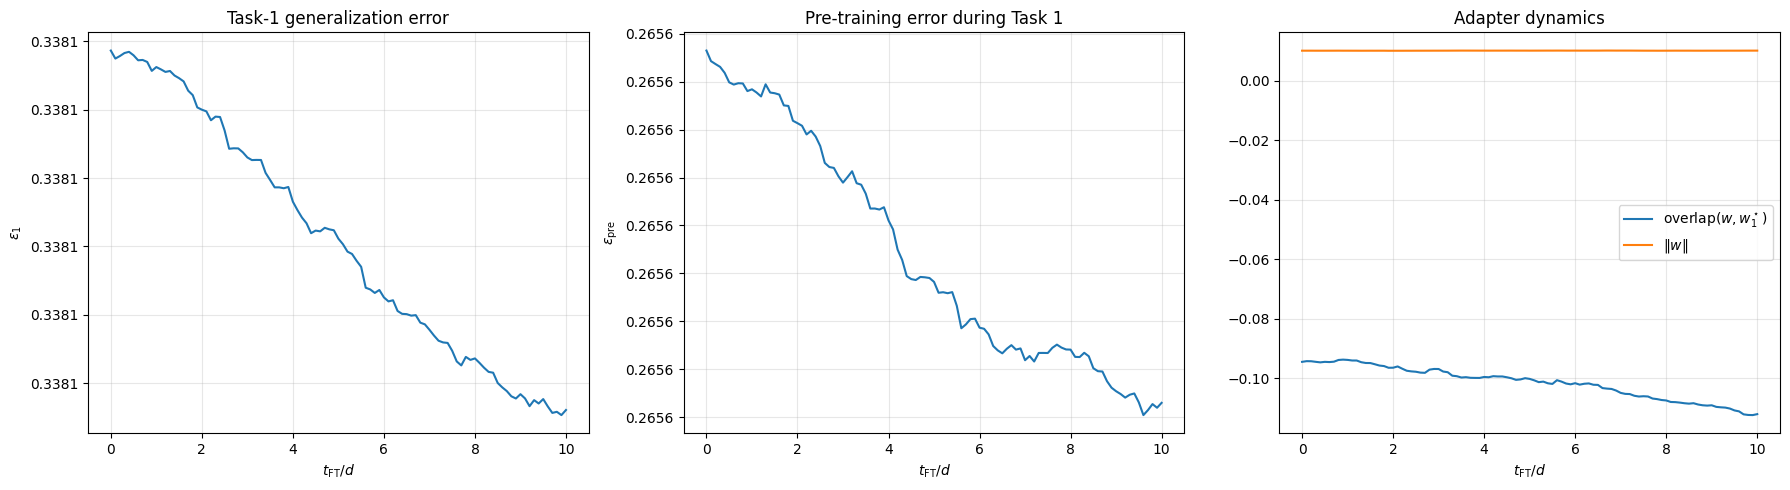

In [53]:

RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 0

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
91,50000,910,9.1,0.562478,0.161232,0.239376,-0.112299,0.010118
92,50000,920,9.2,0.562478,0.161232,0.239376,-0.112469,0.010117
93,50000,930,9.3,0.562478,0.161232,0.239376,-0.112633,0.010118
94,50000,940,9.4,0.562478,0.161232,0.239376,-0.113017,0.010122
95,50000,950,9.5,0.562478,0.161232,0.239376,-0.113870,0.010121
96,50000,960,9.6,0.562478,0.161232,0.239376,-0.114262,0.010122
97,50000,970,9.7,0.562478,0.161232,0.239376,-0.115091,0.010127
98,50000,980,9.8,0.562478,0.161232,0.239376,-0.115338,0.010132
99,50000,990,9.9,0.562478,0.161232,0.239376,-0.115259,0.010131
100,50000,1000,10.0,0.562478,0.161232,0.239376,-0.114977,0.010131


pretraining checkpoint : 50,000
finetuning step        : 1,000
t/d                    : 10.000
Task-1 error           : 2.393762e-01
Pretraining error      : 1.612316e-01
Overlap with w1*       : -0.114977
||w||                  : 0.010131


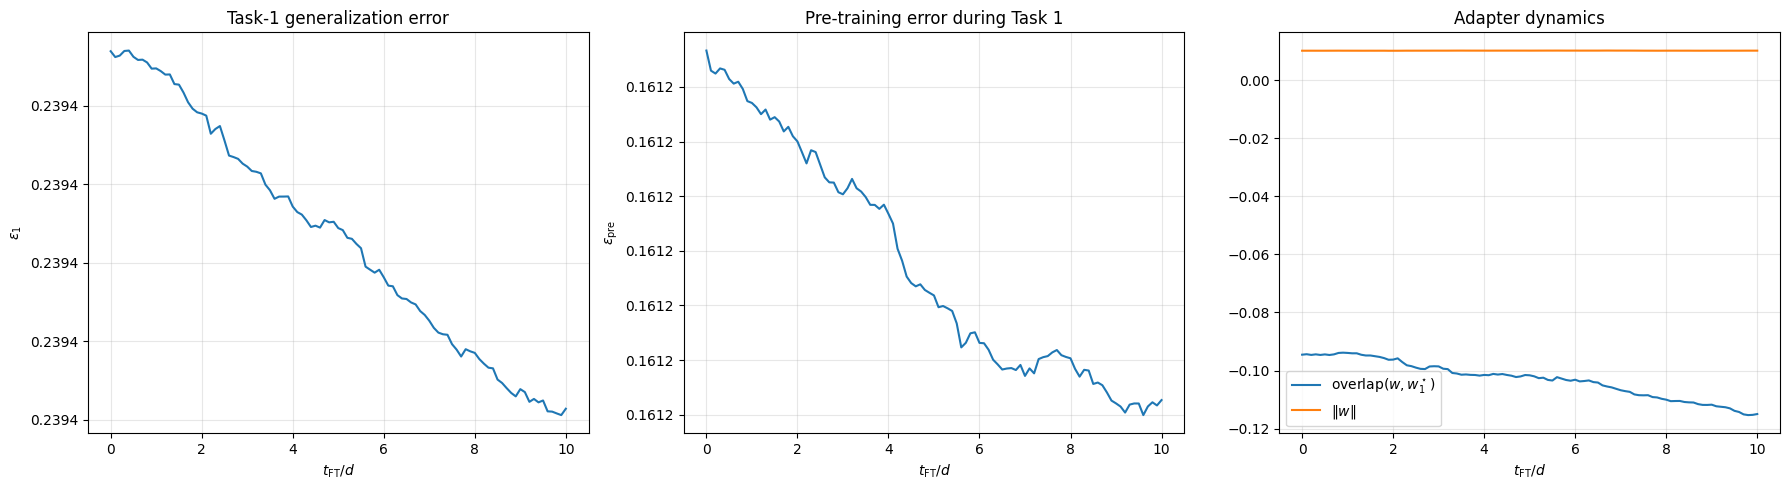

In [54]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 50000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
191,200000,1910,19.1,0.127156,0.034466,0.130192,-0.153545,0.010202
192,200000,1920,19.2,0.127156,0.034466,0.130192,-0.154421,0.010206
193,200000,1930,19.3,0.127156,0.034466,0.130192,-0.154696,0.010208
194,200000,1940,19.4,0.127156,0.034466,0.130192,-0.155584,0.010209
195,200000,1950,19.5,0.127156,0.034466,0.130192,-0.156097,0.010210
196,200000,1960,19.6,0.127156,0.034466,0.130192,-0.155716,0.010212
197,200000,1970,19.7,0.127156,0.034466,0.130192,-0.155830,0.010219
198,200000,1980,19.8,0.127156,0.034466,0.130192,-0.155857,0.010219
199,200000,1990,19.9,0.127156,0.034466,0.130192,-0.156020,0.010211
200,200000,2000,20.0,0.127156,0.034466,0.130192,-0.156587,0.010210


pretraining checkpoint : 200,000
finetuning step        : 2,000
t/d                    : 20.000
Task-1 error           : 1.301916e-01
Pretraining error      : 3.446616e-02
Overlap with w1*       : -0.156587
||w||                  : 0.010210


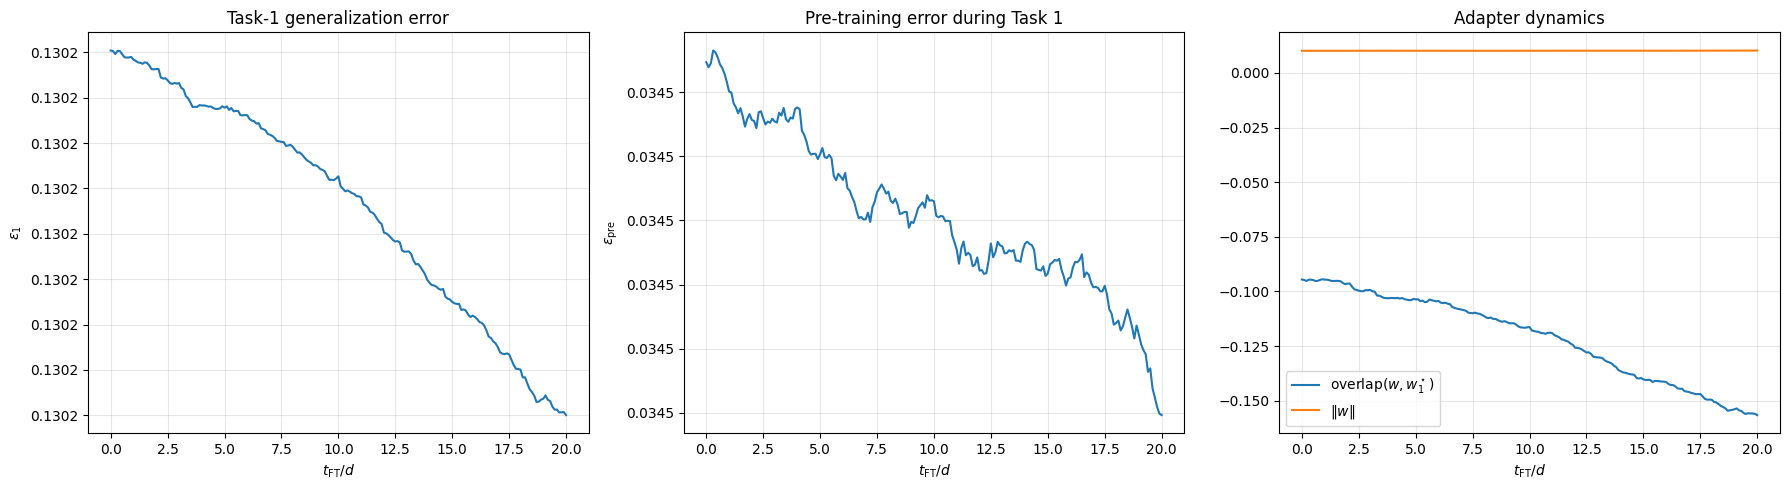

In [57]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 200000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()

,pretraining_step,finetune_step,finetune_step_over_d,representation_error,pretraining_error,task1_error,overlap_w1,w_norm
991,250000,9910,99.1,0.080889,0.021803,0.121303,-0.690684,0.014173
992,250000,9920,99.2,0.080889,0.021803,0.121303,-0.691862,0.014196
993,250000,9930,99.3,0.080889,0.021803,0.121303,-0.692558,0.014210
994,250000,9940,99.4,0.080889,0.021803,0.121303,-0.693405,0.014224
995,250000,9950,99.5,0.080889,0.021803,0.121303,-0.694874,0.014244
996,250000,9960,99.6,0.080889,0.021803,0.121303,-0.695658,0.014259
997,250000,9970,99.7,0.080889,0.021803,0.121303,-0.696256,0.014277
998,250000,9980,99.8,0.080889,0.021803,0.121303,-0.696801,0.014295
999,250000,9990,99.9,0.080889,0.021803,0.121303,-0.697390,0.014306
1000,250000,10000,100.0,0.080889,0.021803,0.121303,-0.697807,0.014338


pretraining checkpoint : 250,000
finetuning step        : 10,000
t/d                    : 100.000
Task-1 error           : 1.213027e-01
Pretraining error      : 2.180273e-02
Overlap with w1*       : -0.697807
||w||                  : 0.014338


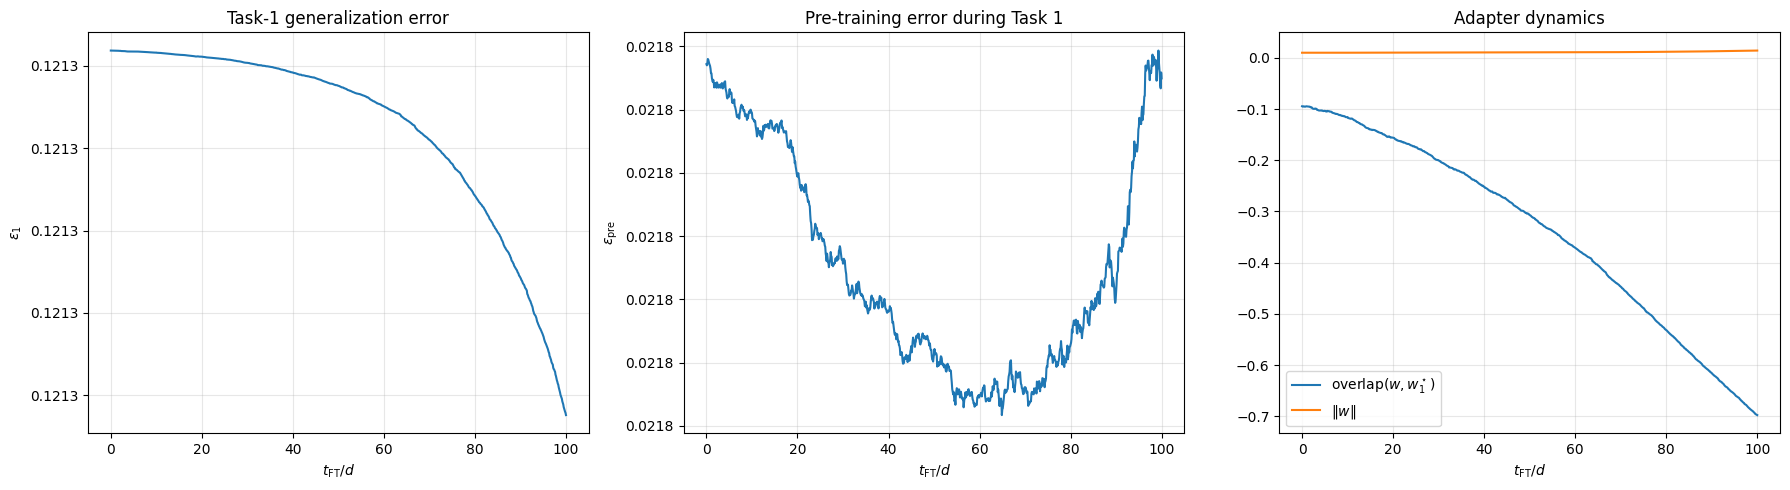

In [60]:
RUN_NAME = "scaling_d100_T5"
PRETRAIN_STEP = 250000

RESULTS_ROOT = (
    REPO_ROOT
    / "results"
    / "task1_finetuning"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

METRICS_PATH = (
    RUN_DIR
    / f"step_{PRETRAIN_STEP}_task1_metrics.csv"
)


# ============================================================
# Load current metrics
# ============================================================

if not METRICS_PATH.exists():
    raise FileNotFoundError(
        f"No metrics found yet:\n{METRICS_PATH}"
    )

df = pd.read_csv(METRICS_PATH)

df = (
    df
    .sort_values("finetune_step")
    .drop_duplicates(
        subset="finetune_step",
        keep="last",
    )
    .reset_index(drop=True)
)

display(df.tail(10))


# ============================================================
# Current status
# ============================================================

last = df.iloc[-1]

print(
    f"pretraining checkpoint : {PRETRAIN_STEP:,}"
)
print(
    f"finetuning step        : "
    f"{int(last['finetune_step']):,}"
)
print(
    f"t/d                    : "
    f"{last['finetune_step_over_d']:.3f}"
)
print(
    f"Task-1 error           : "
    f"{last['task1_error']:.6e}"
)
print(
    f"Pretraining error      : "
    f"{last['pretraining_error']:.6e}"
)
print(
    f"Overlap with w1*       : "
    f"{last['overlap_w1']:.6f}"
)
print(
    f"||w||                  : "
    f"{last['w_norm']:.6f}"
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)


# ------------------------------------------------------------
# Task-1 generalization error
# ------------------------------------------------------------

axes[0].plot(
    df["finetune_step_over_d"],
    df["task1_error"],
)

axes[0].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[0].set_ylabel(
    r"$\epsilon_1$"
)
axes[0].set_title(
    "Task-1 generalization error"
)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Pretraining error during fine-tuning
# ------------------------------------------------------------

axes[1].plot(
    df["finetune_step_over_d"],
    df["pretraining_error"],
)

axes[1].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[1].set_ylabel(
    r"$\epsilon_{\mathrm{pre}}$"
)
axes[1].set_title(
    "Pre-training error during Task 1"
)
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Adapter alignment
# ------------------------------------------------------------

axes[2].plot(
    df["finetune_step_over_d"],
    df["overlap_w1"],
    label=r"$\mathrm{overlap}(w,w_1^\star)$",
)

axes[2].plot(
    df["finetune_step_over_d"],
    df["w_norm"],
    label=r"$\|w\|$",
)

axes[2].set_xlabel(r"$t_{\mathrm{FT}}/d$")
axes[2].set_title(
    "Adapter dynamics"
)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

for ax in axes[:2]:
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )

from matplotlib.ticker import FormatStrFormatter

axes[0].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

axes[1].yaxis.set_major_formatter(
    FormatStrFormatter("%.4f")
)

plt.tight_layout()
plt.show()